# Breast-Cancer Diagnostic Benchmark with Scaled SVMs

Developed a reproducible classification benchmark on the Wisconsin Diagnostic Breast Cancer dataset. Used fold-local scaling and cross-validation to select an SVM, then achieved 97.37% accuracy on a held-out 114-record test set compared with 92.11% for an unscaled linear-SVM baseline. Included class-level evaluation, an accuracy confidence interval and clear limits on clinical interpretation.

This notebook reviews saved results. The experiment script was executed separately. Enable the optional rerun only after configuring your dataset.

## Method

Compared an unscaled linear-SVM baseline with scaled SVM/logistic candidates. Fitted scaling within each training fold, selected hyperparameters by five-fold training ROC-AUC, and evaluated once on a held-out 114-record test set.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
root = Path.cwd()
metrics = json.loads((root / 'results' / 'metrics.json').read_text(encoding='utf8'))
if 'test_results' in metrics:
    display(pd.DataFrame(metrics['test_results']).T)
else:
    display(pd.DataFrame({'value': {k:v for k,v in metrics.items() if isinstance(v,(str,int,float))}}))

,accuracy,balanced_accuracy,macro_f1,weighted_f1,roc_auc,average_precision
Unscaled linear SVM baseline,0.921053,0.902778,0.912837,0.919879,0.991733,0.985609
Selected scaled model,0.973684,0.964286,0.971277,0.973465,0.995701,0.993951


## Recorded environment and data provenance

In [2]:
display(metrics.get('environment', {}))
print('Data fingerprint:', metrics.get('input_sha256', metrics.get('audit',{}).get('input_sha256','see dataset checksums')))

{'python': '3.12.2',
 'numpy': '2.5.3',
 'pandas': '3.0.6',
 'sklearn': '1.9.1',
 'scipy': '1.18.1',
 'seed': 42}

Data fingerprint: see dataset checksums


## Figures

test_confusion_matrix.png


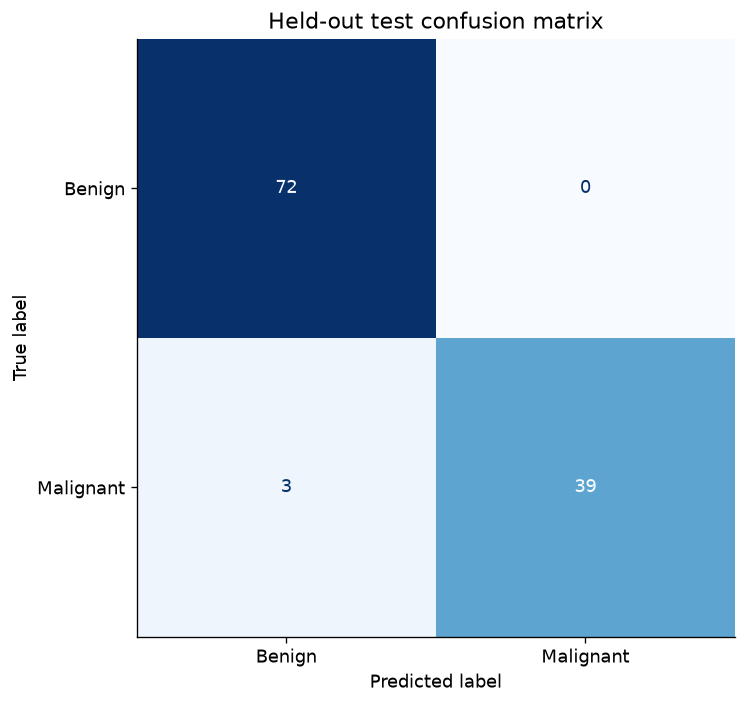

In [3]:
for figure in sorted((root / 'results').glob('*.png')):
    print(figure.name)
    display(Image(filename=str(figure)))

## Interpretation and limitations

Selected test accuracy is 97.37% (111/114), with a Wilson 95% interval of approximately 92.55%–99.10%. The same-split unscaled baseline reached 92.11%. This is a small educational benchmark and has no clinical validation; it must not be represented as a diagnostic product.

## Optional full rerun

Adjust the dataset path in the command. This may download files or train a model and can take time. Results below are never produced from synthetic placeholder data.

In [4]:
RERUN_EXPERIMENT = False
if RERUN_EXPERIMENT:
    import subprocess, sys, shlex
    command = 'python train.py --out results'
    subprocess.run([sys.executable] + shlex.split(command)[1:], cwd=root, check=True)